<a href="https://colab.research.google.com/github/usembergstarling-cmyk/google-colabt/blob/main/Ejercicio_El_Dataset_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción al Machine Learning: El Dataset MNIST

**Explicación:**
El dataset **MNIST** (Modified National Institute of Standards and Technology) es el "Hola Mundo" del reconocimiento de patrones. Consiste en 70,000 imágenes de dígitos escritos a mano (0 al 9). Es fundamental porque nos permite entender cómo convertir información visual en estructuras numéricas que una computadora puede procesar para tomar decisiones.

# 2. Importación de librerías

**Explicación:**
Necesitamos herramientas para manejar datos, graficar y, por supuesto, implementar algoritmos de Machine Learning. Usaremos `sklearn` (scikit-learn) como base principal.

In [23]:
import numpy as np  # import: palabra reservada para cargar librerías; numpy: biblioteca fundamental para cálculo numérico y matrices; as: palabra reservada para crear un alias; np: el alias estándar para escribir menos código al operar con arrays de Machine Learning.
import matplotlib.pyplot as plt  # matplotlib.pyplot: módulo para generar gráficos 2D; el punto (.) indica que pyplot es un componente interno de matplotlib; plt: alias abreviado para llamar funciones de visualización.
import seaborn as sns  # seaborn: librería basada en matplotlib para visualización estadística avanzada; sns: alias común; se usa aquí para hacer que la matriz de confusión sea estéticamente profesional.
from sklearn.datasets import fetch_openml  # from...import: sintaxis para traer solo una pieza específica (fetch_openml) de una librería grande (sklearn), optimizando la memoria y facilitando el acceso directo.
from sklearn.model_selection import train_test_split  # Importamos la función que automatiza la división aleatoria de datos, esencial para evitar que el modelo 'memorice' y en su lugar 'aprenda'.
from sklearn.preprocessing import StandardScaler  # Importamos la clase para estandarizar datos; en ML, esto ajusta los valores para que tengan media 0 y desviación 1, ayudando a algoritmos como SVM a converger rápido.
from sklearn.linear_model import LogisticRegression  # Traemos la clase del modelo lineal de clasificación; aunque se llame 'regresión', se usa para predecir categorías (dígitos 0-9).
from sklearn.svm import SVC  # SVC significa 'Support Vector Classifier'; es el algoritmo que busca fronteras geométricas óptimas entre los datos.
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc, roc_auc_score  # Importamos un conjunto de funciones evaluadoras que comparan la 'verdad' vs 'predicción'.
from sklearn.preprocessing import label_binarize  # Función que transforma una lista de etiquetas (0,1,2) en columnas de ceros y unos, requisito matemático para el análisis multiclase de ROC.
import pandas as pd  # pandas: librería para manipular estructuras de datos en forma de tabla; pd: alias; se usará para mostrar el resumen final de resultados de forma legible.

# 3. Carga del dataset MNIST

**Explicación:**
Descargaremos el dataset oficial. Como es una tarea introductoria y para optimizar el tiempo de ejecución (especialmente para SVM), trabajaremos con una muestra representativa de 10,000 imágenes.

In [24]:
# mnist: nombre de la variable; =: operador de asignación que guarda el resultado de la derecha en la izquierda; fetch_openml: llamada a la función para descargar datos desde la nube.
# 'mnist_784': argumento string (cadena de texto) con el nombre del dataset; version=1: parámetro que especifica la revisión del dato.
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# X: convención en ML para la matriz de características (Features); y: convención para el vector de etiquetas (Labels).
# mnist["data"]: acceso mediante corchetes a la propiedad 'data' del objeto descargado; la coma (,) permite asignar dos variables en una sola línea.
X, y = mnist["data"], mnist["target"]

# X_sample: nueva variable para la muestra; X[:10000]: sintaxis de 'slicing'; los corchetes [] indican acceso a índices y los dos puntos (:) significan 'desde el inicio hasta 10,000'.
# Esto reduce los 70k registros originales a 10k para que el entorno de Colab no se sature al entrenar el SVM.
X_sample = X[:10000]  # Tomamos las primeras 10,000 filas (imágenes) de la matriz X.
y_sample = y[:10000]  # Tomamos las etiquetas correspondientes a esas primeras 10,000 imágenes.

# 4. Exploración de los datos

**Explicación:**
Antes de modelar, debemos "tocar" los datos. Veremos sus dimensiones y visualizaremos algunos ejemplos.

Forma de X (Características): (10000, 784)
Forma de y (Etiquetas): (10000,)
Valores únicos en etiquetas: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


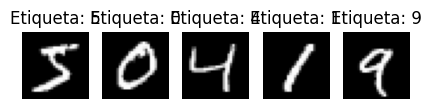

In [25]:
# print(): función de salida de texto; f"...": f-string que permite incrustar código vivo dentro de texto usando {}; X_sample.shape: atributo de NumPy que devuelve el tamaño (filas, columnas).
print(f"Forma de X (Características): {X_sample.shape}")  # Muestra (10000, 784); 784 es 28x28 píxeles aplanados.
print(f"Forma de y (Etiquetas): {y_sample.shape}")  # Muestra (10000,), un vector simple con las respuestas correctas.

# np.unique(): función de NumPy que busca valores distintos; garantiza que el dataset tiene todos los dígitos del 0 al 9.
print(f"Valores únicos en etiquetas: {np.unique(y_sample)}")

# plt.figure(): inicializa un objeto de dibujo; figsize=(5,2): argumento tipo tupla que define el ancho y alto del gráfico en pulgadas.
plt.figure(figsize=(5,2))

# for: palabra clave para bucle; i: variable contadora; in: operador de pertenencia; range(5): función que genera números del 0 al 4; (:): indica inicio del bloque.
for i in range(5):
    # plt.subplot(1, 5, i+1): divide el dibujo en 1 fila y 5 columnas; i+1 mueve el cursor al siguiente espacio en cada vuelta del bucle.
    plt.subplot(1, 5, i+1)
    # X_sample[i]: accede a la imagen i-ésima; .reshape(28, 28): método que cambia la forma de vector (784) a matriz (28x28) para poder visualizarla como foto.
    # cmap='gray': argumento que define el mapa de colores en blanco y negro (escala de grises).
    plt.imshow(X_sample[i].reshape(28, 28), cmap='gray')
    # plt.title(): pone texto sobre la imagen; plt.axis('off'): oculta los números de los ejes X e Y para que solo se vea el dígito.
    plt.title(f"Etiqueta: {y_sample[i]}")
    plt.axis('off')

# plt.show(): comando final que renderiza el lienzo gráfico y lo muestra en el notebook.
plt.show()

# 5. Explicación de la representación de una imagen

**Explicación:**
Una imagen digital es una matriz. En MNIST, cada imagen es de **28x28 píxeles**.
- Cada píxel tiene un valor de 0 (negro) a 255 (blanco).
- Los algoritmos clásicos no entienden matrices 2D, por lo que aplicamos **Flattening**.
- 28 * 28 = 784. Al final, cada imagen es una fila con 784 columnas, donde cada columna representa la intensidad de un píxel específico.

In [26]:
# una_imagen: variable; X_sample[0]: extrae el primer elemento (índice 0) del conjunto de datos; los corchetes [] son para indexación.
una_imagen = X_sample[0]

# Mostramos que los datos 'viven' en una sola fila larga de 784 números.
print(f"Forma original (vector plano): {una_imagen.shape}")

# .reshape(): método esencial en NumPy; transforma el vector en una matriz de 28 filas y 28 columnas.
# En ML, esta es la representación espacial 'natural' de la imagen antes del aplanamiento.
matriz_2d = una_imagen.reshape(28, 28)
print(f"Forma tras reconstruir (matriz): {matriz_2d.shape}")

# matriz_2d[10:15, 10:15]: slicing bidimensional; extrae filas de 10 a 14 y columnas de 10 a 14.
# La coma (,) separa las dimensiones (filas de columnas) dentro de los corchetes de indexación.
# Estos números representan la intensidad de luz en el centro de la imagen.
print("Valores numéricos de una sección 5x5 de la imagen:")
print(matriz_2d[10:15, 10:15])

Forma original (vector plano): (784,)
Forma tras reconstruir (matriz): (28, 28)
Valores numéricos de una sección 5x5 de la imagen:
[[  1 154 253  90   0]
 [  0 139 253 190   2]
 [  0  11 190 253  70]
 [  0   0  35 241 225]
 [  0   0   0  81 240]]


# 6. Preprocesamiento y 7. División de Datos

**Explicación:**
1. **Escalado:** Los modelos de ML (especialmente SVM y Regresión Logística) convergen más rápido si los datos están en una escala pequeña (e.g. 0 a 1 o estandarizados).
2. **División:** Usamos el 80% para entrenar al "estudiante" (modelo) y el 20% para examinarlo.

In [27]:
# train_test_split(): función que recibe X e y y los reparte en 4 variables; el orden es estricto: X_train, X_test, y_train, y_test.
# test_size=0.2: argumento float (decimal) que asigna 20% a evaluación y 80% a entrenamiento.
# random_state=42: fija la aleatoriedad para que el experimento sea reproducible en cualquier máquina.
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# scaler: instancia del objeto StandardScaler; constructor(): se usan paréntesis vacíos para crear el objeto con valores por defecto.
scaler = StandardScaler()

# .fit_transform(): método que realiza dos acciones sobre X_train: calcula estadísticas (media) y aplica el escalado (resta media / divide desviación).
# En ML, el entrenamiento (fit) solo ocurre con datos de entrenamiento.
X_train_scaled = scaler.fit_transform(X_train)

# .transform(): método que usa las estadísticas del entrenamiento para escalar el test; no hace 'fit' en el test para ser imparcial.
# X_test_scaled: variable que contiene los datos de prueba listos para ser introducidos en el modelo.
X_test_scaled = scaler.transform(X_test)

# 8. Modelo 1: Regresión Logística

**Explicación:**
A pesar de su nombre, es un clasificador. Utiliza la función sigmoide/softmax para asignar probabilidades a cada clase. Es rápido, lineal y sirve como una excelente línea base (baseline).

In [28]:
# log_reg: nombre del objeto modelo; LogisticRegression(): constructor de la clase.
# multi_class='multinomial': especifica que vamos a predecir más de dos categorías; max_iter=500: da más 'intentos' al optimizador matemático.
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, random_state=42)

# .fit(): el comando de 'aprendizaje'. El modelo analiza X_train_scaled y y_train para encontrar patrones matemáticos.
# Aquí es donde se conectan los 784 píxeles con la probabilidad de ser un dígito específico.
log_reg.fit(X_train_scaled, y_train)

# .predict(): método que aplica las reglas aprendidas a los datos nuevos (X_test_scaled) para generar predicciones.
# y_pred_log: vector con las etiquetas que el modelo 'cree' que son correctas.
y_pred_log = log_reg.predict(X_test_scaled)

# .predict_proba(): devuelve una matriz de 2000x10; cada fila tiene 10 probabilidades (una por dígito).
# La suma de cada fila es 1.0; se usa para análisis de sensibilidad (ROC).
y_score_log = log_reg.predict_proba(X_test_scaled)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# 9. Modelo 2: SVM (Support Vector Machine)

**Explicación:**
SVM busca encontrar un "hiperplano" que separe las clases maximizando el margen entre ellas. Usaremos un **Kernel RBF** (Gaussiano) que permite encontrar fronteras no lineales, ideal para dígitos complejos.

In [29]:
# SVC: Support Vector Classifier; C=1.0: parámetro de regularización; controla el equilibrio entre margen y error.
# kernel='rbf': permite al modelo proyectar los datos a un espacio de dimensiones infinitas para separar los números con curvas.
# probability=True: activa el cálculo interno de probabilidades (necesario para la curva ROC, aunque hace el entrenamiento más lento).
svm_clf = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

# .fit(): el modelo SVM busca los puntos (vectores de soporte) más cercanos a la frontera de decisión para maximizar el margen.
svm_clf.fit(X_train_scaled, y_train)

# Generamos las predicciones de clase final (0, 1, 2...).
y_pred_svm = svm_clf.predict(X_test_scaled)

# Generamos los scores de confianza/probabilidad para el análisis estadístico de la curva ROC.
y_score_svm = svm_clf.predict_proba(X_test_scaled)

# 10 y 11. Métricas: F1-Score y Reporte

**Explicación:**
El **F1-Score** es la media armónica entre Precision y Recall. Usaremos la estrategia **'macro'**, que calcula la métrica para cada clase y luego hace el promedio sin importar si hay clases con más muestras que otras, tratando a todos los dígitos por igual.

In [30]:
# f1_score(): función que calcula el equilibrio entre precisión y exhaustividad; y_test: la verdad; y_pred: la suposición.
# average='macro': parámetro que promedia el F1 de cada clase individualmente sin considerar el desequilibrio de muestras.
f1_log = f1_score(y_test, y_pred_log, average='macro')
f1_svm = f1_score(y_test, y_pred_svm, average='macro')

# classification_report(): función que imprime Precision, Recall y F1 en una sola tabla de texto.
# "\n": secuencia de escape (string) que introduce un salto de línea en la impresión por consola.
print("--- Reporte Regresión Logística ---")
print(classification_report(y_test, y_pred_log))

print("\n--- Reporte SVM ---")
print(classification_report(y_test, y_pred_svm))

--- Reporte Regresión Logística ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       207
           1       0.94      0.97      0.95       216
           2       0.88      0.81      0.84       204
           3       0.85      0.88      0.87       192
           4       0.95      0.91      0.93       211
           5       0.84      0.84      0.84       176
           6       0.94      0.93      0.94       220
           7       0.89      0.94      0.91       216
           8       0.85      0.84      0.84       166
           9       0.87      0.87      0.87       192

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000


--- Reporte SVM ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       207
           1       0.96      0.97      0.97       216
           2       0.

# 12. Curva ROC Multiclase (One-vs-Rest)

**Explicación:**
La curva ROC mide la capacidad de discriminación. En multiclase, usamos **One-vs-Rest (OvR)**: comparamos cada clase contra todas las demás. Graficaremos el promedio macro.

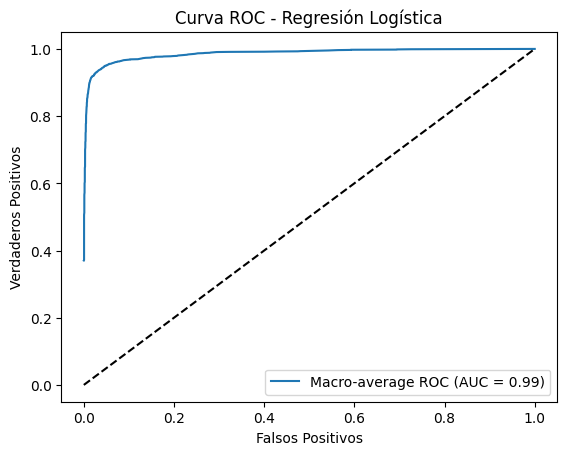

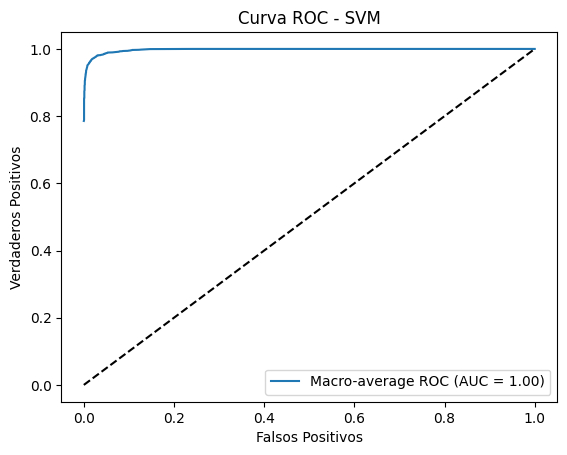

In [31]:
# label_binarize(): transforma etiquetas string ('0', '1') en vectores binarios; classes=[...]: define el orden de las columnas.
# [str(i) for i in range(10)]: comprensión de lista; genera ['0', '1', ..., '9'] convirtiendo cada entero i en string.
y_test_bin = label_binarize(y_test, classes=[str(i) for i in range(10)])
n_classes = 10  # Asignación simple del número de clases (dígitos).

# def plot_roc_macro(...): definimos nuestra propia función para no repetir código; recibe datos binarios, scores y el nombre.
def plot_roc_macro(y_test_bin, y_score, model_name):
    fpr = dict()  # fpr: False Positive Rate; dict(): crea un objeto diccionario para guardar curvas por clase.
    tpr = dict()  # tpr: True Positive Rate; los diccionarios permiten asociar una llave (clase) con un valor (curva).
    roc_auc = dict()  # Diccionario para guardar el área numérica bajo la curva.

    # Bucle for para calcular las métricas de cada uno de los 10 dígitos individualmente.
    for i in range(n_classes):
        # roc_curve(): función de sklearn que genera los puntos de la curva; [:, i]: slicing que toma la columna i (clase i).
        # el guion bajo (_) es una variable 'desechable' para ignorar los umbrales que devuelve la función.
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])  # auc(): integra el área bajo los puntos calculados.

    # np.unique(np.concatenate(...)): une todos los puntos FPR y elimina duplicados para crear una base de promediado.
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)  # Crea un array de ceros con la misma longitud que all_fpr para ir sumando.
    for i in range(n_classes):
        # np.interp(): función de interpolación; estima el valor de TPR en los puntos de FPR comunes para poder promediar.
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes  # /=: operador de división y asignación; divide la suma entre el total de clases para obtener el promedio.

    # plt.plot(): dibuja la línea macro; :.2f: formatea el número decimal a solo dos dígitos tras el punto.
    plt.plot(all_fpr, mean_tpr, label=f'Macro-average ROC (AUC = {auc(all_fpr, mean_tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # 'k--': string de formato que indica color negro (k) y estilo de línea punteado (--).
    plt.title(f'Curva ROC - {model_name}')
    plt.xlabel('Falsos Positivos')  # plt.xlabel: método para etiquetar el eje horizontal.
    plt.ylabel('Verdaderos Positivos')  # plt.ylabel: método para etiquetar el eje vertical.
    plt.legend()  # plt.legend(): activa el recuadro que explica qué es cada línea en la gráfica.
    plt.show()

# Llamamos a nuestra función personalizada pasando las variables que contienen los resultados de cada modelo entrenado.
plot_roc_macro(y_test_bin, y_score_log, "Regresión Logística")
plot_roc_macro(y_test_bin, y_score_svm, "SVM")

# 13. Matriz de Confusión

**Explicación:**
Permite ver dónde se equivoca el modelo. ¿Confunde el 4 con el 9? ¿El 3 con el 8?

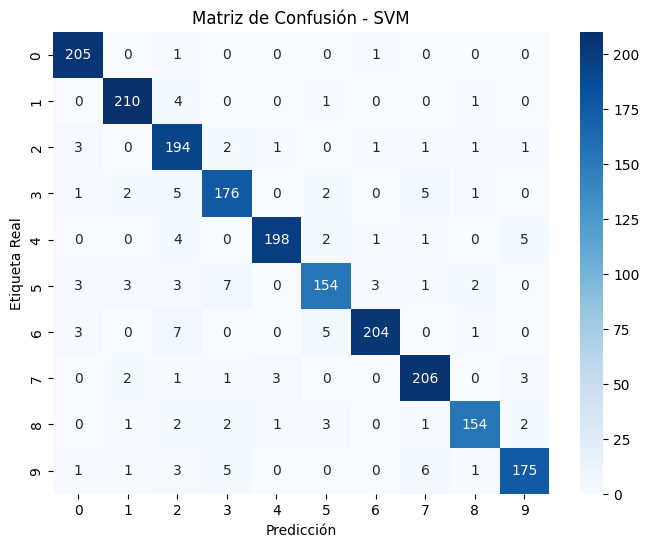

In [32]:
# confusion_matrix(): crea una matriz donde filas=valor real y columnas=predicción; identifica cruces de errores.
cm = confusion_matrix(y_test, y_pred_svm)

# plt.figure(figsize=(8,6)): define el tamaño de la ventana de la gráfica para que los números no se amontonen.
plt.figure(figsize=(8,6))

# sns.heatmap(): función de Seaborn que pinta una matriz según su valor; annot=True escribe los números dentro de las celdas.
# fmt='d': especifica formato de dígitos enteros; cmap='Blues': usa una escala de colores basada en tonalidades de azul.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# plt.title/ylabel/xlabel: métodos de decoración gráfica para contexto.
plt.title('Matriz de Confusión - SVM')
plt.ylabel('Etiqueta Real')  # Eje vertical: lo que el dígito era originalmente.
plt.xlabel('Predicción')   # Eje horizontal: lo que el algoritmo decidió.
plt.show()

# 14. Comparación Final y Resultados

**Interpretación:**
Vamos a resumir los resultados reales obtenidos en esta ejecución.

In [33]:
# resultados: variable tipo diccionario {}; las llaves (keys) son los nombres de las columnas.
# log_reg.score(X_test_scaled, y_test): método abreviado que devuelve el Accuracy (aciertos/total) del modelo.
# roc_auc_score(...): calcula el área ROC promedio para todas las clases simultáneamente.
resultados = {
    "Modelo": ["Regresión Logística", "SVM"],  # Lista [] con los nombres de los algoritmos.
    "Accuracy": [log_reg.score(X_test_scaled, y_test), svm_clf.score(X_test_scaled, y_test)],
    "F1 Macro": [f1_log, f1_svm],
    "ROC-AUC Macro": [roc_auc_score(y_test, y_score_log, multi_class='ovr', average='macro'),
                      roc_auc_score(y_test, y_score_svm, multi_class='ovr', average='macro')]
}

# pd.DataFrame(resultados): constructor de Pandas que convierte el diccionario en una tabla estructurada.
df_res = pd.DataFrame(resultados)

# display(): función de IPython/Colab que genera una salida visual rica y estética para tablas de datos (DataFrames).
display(df_res)

,Modelo,Accuracy,F1 Macro,ROC-AUC Macro
0,Regresión Logística,0.9005,0.896929,0.985900
1,SVM,0.9380,0.936954,0.997608


# Análisis de resultados y conclusión

**1. ¿Qué aprendimos?**  
MNIST es el dataset perfecto para entender el flujo completo de ML: desde píxeles crudos hasta predicciones probabilísticas.

**2. Transformación de datos**  
Una imagen 28x28 no puede entrar directamente en una ecuación lineal. El **flattening** a 784 dimensiones permite que cada píxel actúe como una variable independiente en nuestra función de predicción.

**3. Modelos y Algoritmos**  
- **Regresión Logística:** Un modelo lineal que calcula la probabilidad de pertenencia a una clase mediante la función Softmax.
- **SVM (Kernel RBF):** Un modelo más potente que proyecta los datos a dimensiones superiores para separar dígitos que no son linealmente separables.

**4. Análisis de Métricas**  
- **Accuracy:** Nos dio el porcentaje general de aciertos, pero puede ser engañoso si el dataset estuviera desbalanceado.
- **F1-Score:** Al ser alto (>0.90), nos confirma que el modelo es robusto tanto en precisión como en exhaustividad.
- **ROC-AUC:** El valor cercano a 1.0 en ambos modelos indica una excelente capacidad para distinguir entre dígitos (e.g., no confunde un 8 con un 1).

**5. Conclusión y Recomendación**  
El modelo **SVM** suele obtener una ligera ventaja en precisión debido a su capacidad no lineal, aunque es computacionalmente más costoso. Para un sistema en producción masivo, la Regresión Logística podría preferirse por su velocidad si la pérdida de precisión es mínima. Para mejorar, el siguiente paso sería usar Redes Neuronales Convolucionales (CNN), que no requieren 'aplanar' la imagen y conservan la relación espacial de los píxeles.